# Setup

All the Imports needed for this experiment.

In [1]:
from matplotlib import pyplot as plt
from collections import defaultdict
import gymnasium as gym
import numpy as np
import ipywidgets as widgets
from datetime import datetime

import sys
from pathlib import Path
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "env" / "blackjack_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from env.blackjack_env import BlackjackEnv
from agents.q_learning_agent import QLearningBlackjackAgent


Define default font size, plot colors etc.

In [2]:
def setup_plot_style():
    """Definiert das globale Design für alle Matplotlib-Plots."""
    # Schriftgrößen
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 11
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    
    # Linien & Grid
    plt.rcParams['lines.linewidth'] = 2.0
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.5
    
    # Layout & Render-Qualität
    plt.rcParams['figure.autolayout'] = True
    plt.rcParams['figure.dpi'] = 120
    
    # Optionale Farbpalette (z.B. "Tab10" oder "Set2" für modernen Look)
    plt.style.use('seaborn-v0_8-whitegrid') # Falls ein Grundtheme gewünscht ist

setup_plot_style()
AGENT_STYLES = {    
    "baseline": {"color": "#6b7c93", "label": "Baseline"},
    "counting":  {"color": "#2a9d8f", "label": "Counting"},
}


Create image folder for high-res images and image save function.

In [3]:
IMAGES_PATH = PROJECT_ROOT / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    print(f"Figure saved: {path}")

# Environment & Agents

In [4]:
def baseline_state_key(obs) -> tuple[int, int, int]:
    player_total, dealer_upcard, usable_ace = obs[:3]

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace)
    )

def counting_state_key(obs: np.ndarray):
    import numpy as np
    player_total, dealer_upcard, usable_ace, running_count, true_count, cards_remaining = obs

    return (
        int(player_total),
        int(dealer_upcard),
        int(usable_ace),

        int(np.clip(running_count, -20, 20)),
        int(np.clip(true_count, -10, 10)),
        int(np.clip(cards_remaining // 52, 0, 6)),
    )


class BaselineBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=baseline_state_key,
            **kwargs,
        )
        
class CountingBlackjackAgent(QLearningBlackjackAgent):
    def __init__(
            self, 
            env: gym.Env,
            **kwargs):
        
        super().__init__(
            env=env,
            state_encoder=counting_state_key,
            **kwargs,
        )

In [5]:
SEEDS = [1, 42, 123]
EPISODES_PER_SEED = 100_000
EVAL_SEEDS = [1234, 4321, 9876]
EVAL_EPISODES = 10_000
CHECKPOINT_INTERVAL = 5_000_000
SAVE_FINAL_MODELS = True
MODEL_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR = MODEL_DIR / "checkpoints"
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

agent_config = {
    "learning_rate": 0.01,
    "initial_epsilon": 1.0,
    "final_epsilon": 0.10,
    "epsilon_decay": (1.0 - 0.10) / (EPISODES_PER_SEED * 0.90),
    "discount_factor": 0.99,
}

def make_env(seed: int, n_episodes: int):
    env = BlackjackEnv(
        num_decks=6,
        penetration=0.75,
        stand_on_soft_17=True,
    )

    env = gym.wrappers.RecordEpisodeStatistics(
        env,
        buffer_length=n_episodes,
    )

    env.reset(seed=seed)
    env.action_space.seed(seed)

    return env

agents = {}

for seed in SEEDS:
    agents[f"baseline-{seed}"] = BaselineBlackjackAgent(
        env=make_env(seed, EPISODES_PER_SEED),
        **agent_config,
    )
    agents[f"counting-{seed}"] = CountingBlackjackAgent(
        env=make_env(seed, EPISODES_PER_SEED),
        **agent_config,
    )

def split_agent_name(name: str) -> tuple[str, int]:
    agent_type, seed = name.rsplit("-", 1)
    return agent_type, int(seed)

def group_agents_by_type(agents):
    grouped = defaultdict(list)

    for name, agent in agents.items():
        agent_type, seed = split_agent_name(name)
        grouped[agent_type].append((seed, agent))

    return grouped


In [6]:
# Checkpoint-Auswahl fuer Training und Evaluation
NO_ARTIFACT = None
IN_MEMORY_ARTIFACT = "__in_memory__"

def artifact_label(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def artifact_options(agent_name: str, include_fresh: bool = False, include_memory: bool = False):
    options = []
    if include_fresh:
        options.append(("Neu trainieren (kein gespeichertes Modell laden)", NO_ARTIFACT))
    if include_memory:
        options.append(("Aktueller Agent im Speicher", IN_MEMORY_ARTIFACT))

    candidates = []
    final_model_suffix = f"_{agent_name}_agent.pkl"
    candidates.extend(
        path for path in MODEL_DIR.glob("*.pkl")
        if path.name.endswith(final_model_suffix)
    )
    candidates.extend((CHECKPOINT_DIR / agent_name).glob("*.pkl"))
    candidates = sorted(
        {path.resolve(): path for path in candidates}.values(),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )

    options.extend((artifact_label(path), str(path)) for path in candidates)
    return options

TRAIN_ARTIFACT_SELECTORS = {
    name: widgets.Dropdown(
        options=artifact_options(name, include_fresh=True),
        value=NO_ARTIFACT,
        description=f"{name}:",
        layout=widgets.Layout(width="760px"),
    )
    for name in agents
}

display(widgets.VBox([widgets.HTML("<b>Training fortsetzen ab:</b>"), *TRAIN_ARTIFACT_SELECTORS.values()]))


# Training

In [7]:
from utils.training import train_single_agent, run_parallel_with_dashboard

if __name__ == "__main__":
    tasks = []
    for name, agent in agents.items():
        agent_type, seed = split_agent_name(name)
        selected_artifact = TRAIN_ARTIFACT_SELECTORS[name].value

        tasks.append((
            name, agent, agent_type, seed, selected_artifact,
            EPISODES_PER_SEED, CHECKPOINT_INTERVAL, CHECKPOINT_DIR / name, RUN_ID
        ))

    results = run_parallel_with_dashboard(
        worker_func=train_single_agent,
        base_tasks=tasks,
        agent_names=list(agents.keys()),
        max_value_per_agent=EPISODES_PER_SEED,
        title="Training"
    )

    for name, trained_agent in results:
        agents[name] = trained_agent

Initialisiere paralleles Training-Dashboard...



Prozess erfolgreich beendet! Gesamtdauer: 0:00:53


# Saving

In [8]:
timestamp = RUN_ID

MODEL_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_FINAL_MODELS:
    for name, agent in agents.items():
        agent_type, seed = split_agent_name(name)
        print(f"Saving {name} agent...")
        
        filename = f"{timestamp}_{name}_agent.pkl"
        path = MODEL_DIR / filename
        
        agent.save(
            path,
            label=f"{name}_{timestamp}",
            artifact_type="final",
            episode=EPISODES_PER_SEED,
            n_episodes=EPISODES_PER_SEED,
            base_seed=seed,
            metadata={
                "agent_name": name,
                "agent_type": agent_type,
                "run_id": RUN_ID,
                "seed": seed,
                "target_episode": EPISODES_PER_SEED,
            },
            include_history=False,
        )
        print(f"-> Erfolgreich gespeichert unter: {path}")
else:
    print("Finales Speichern ist deaktiviert (SAVE_FINAL_MODELS=False).")


Saving baseline-1 agent...
-> Erfolgreich gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\20260605_191814_baseline-1_agent.pkl
Saving counting-1 agent...
-> Erfolgreich gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\20260605_191814_counting-1_agent.pkl
Saving baseline-42 agent...
-> Erfolgreich gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\20260605_191814_baseline-42_agent.pkl
Saving counting-42 agent...
-> Erfolgreich gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\20260605_191814_counting-42_agent.pkl
Saving baseline-123 agent...
-> Erfolgreich gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\20260605_191814_baseline-123_agent.pkl
Saving counting-123 agent...
-> Erfolgreich gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\20260605_191814_counting-123_agent.pkl


# Evaluation

## Greedy Policy Evaluation


In [9]:
# Auswahl, welches Modell/Checkpoint evaluiert werden soll
EVAL_ARTIFACT_SELECTORS = {
    name: widgets.Dropdown(
        options=artifact_options(name, include_memory=True),
        value=IN_MEMORY_ARTIFACT,
        description=f"{name}:",
        layout=widgets.Layout(width="760px"),
    )
    for name in agents
}

display(widgets.VBox([widgets.HTML("<b>Evaluation-Modell auswaehlen:</b>"), *EVAL_ARTIFACT_SELECTORS.values()]))


In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
from utils.training import run_parallel_with_dashboard
from utils.evaluation import evaluate_single_agent_parallel  # <- Jetzt sauber importiert!
from utils.env_utils import make_blackjack_env             # <- Zentrale Factory nutzen

# =========================================================================
# 1. HILFSFUNKTIONEN & STRATEGIEN
# =========================================================================
AGENT_CLASSES = {
    "baseline": BaselineBlackjackAgent,
    "counting": CountingBlackjackAgent,
}

def make_agent(agent_name: str, seed: int):
    agent_type, _ = split_agent_name(agent_name)
    return AGENT_CLASSES[agent_type](
        env=make_blackjack_env(seed=seed, n_episodes=EVAL_EPISODES), # <- Korrigiert
        **agent_config,
    )

def selected_eval_agent(agent_name: str):
    selected_artifact = EVAL_ARTIFACT_SELECTORS[agent_name].value
    if selected_artifact == IN_MEMORY_ARTIFACT:
        return agents[agent_name], "in_memory"

    _, seed = split_agent_name(agent_name)
    eval_agent = make_agent(agent_name, seed=seed)
    artifact = eval_agent.load(selected_artifact)
    label = artifact.get("label") or artifact_label(Path(selected_artifact))
    return eval_agent, label


def eval_task_name(agent_name: str, eval_seed: int) -> str:
    return f"{agent_name}__eval_seed_{eval_seed}"


def split_eval_task_name(task_name: str) -> tuple[str, int]:
    agent_name, eval_seed = task_name.rsplit("__eval_seed_", 1)
    return agent_name, int(eval_seed)


# =========================================================================
# 2. HAUPTPROZESS (Aufgaben vorbereiten und Runner starten)
# =========================================================================
if __name__ == "__main__":
    tasks = []
    agent_names = []
    
    # Modelle laden / vorbereiten
    for name in agents:
        eval_agent, source_label = selected_eval_agent(name)
        agent_type, _ = split_agent_name(name)
        
        # Bestimme die richtige Encoder-Funktion direkt hier im Hauptthread
        encoder_func = baseline_state_key if agent_type == "baseline" else counting_state_key
        
        for eval_seed in EVAL_SEEDS:
            task_name = eval_task_name(name, eval_seed)
            agent_names.append(task_name)
            tasks.append((
                task_name,
                eval_agent.q_values,
                encoder_func,
                source_label,
                EVAL_EPISODES,
                eval_seed,
            ))
        
    # Den generischen Dashboard-Runner aufrufen
    results = run_parallel_with_dashboard(
        worker_func=evaluate_single_agent_parallel,
        base_tasks=tasks,
        agent_names=agent_names,
        max_value_per_agent=EVAL_EPISODES,
        title="Evaluation"
    )
    
    # Ergebnisse aus dem Pool wieder einsammeln
    greedy_eval_results = {}
    for task_name, metrics in results:
        agent_name, eval_seed = split_eval_task_name(task_name)
        agent_type, train_seed = split_agent_name(agent_name)
        metrics.update({
            "agent_name": agent_name,
            "agent_type": agent_type,
            "train_seed": train_seed,
            "eval_seed": eval_seed,
        })
        greedy_eval_results[task_name] = metrics

    # DataFrame bauen, speichern und anzeigen
    greedy_eval_df = pd.DataFrame(greedy_eval_results).T
    EVALUATION_DIR = MODEL_DIR / "evaluations" / RUN_ID
    EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
    greedy_eval_df.to_csv(EVALUATION_DIR / "greedy_metrics.csv", index_label="eval_run")
    greedy_eval_df.to_json(EVALUATION_DIR / "greedy_metrics.json", orient="index", indent=2)
    print(f"Evaluation gespeichert unter: {EVALUATION_DIR}")
    display(greedy_eval_df)


Initialisiere paralleles Evaluation-Dashboard...



Prozess erfolgreich beendet! Gesamtdauer: 0:00:40
Evaluation gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\evaluations\20260605_191814


,source,episodes,win_rate,loss_rate,push_rate,average_reward,std_reward,action_distribution,agent_name,agent_type,train_seed,eval_seed
baseline-1__eval_seed_1234,in_memory,10000,0.429,0.4736,0.0974,-0.0446,0.949005,"{'stand': 8100, 'hit': 7563}",baseline-1,baseline,1,1234
baseline-1__eval_seed_4321,in_memory,10000,0.4327,0.4727,0.0946,-0.04,0.950684,"{'stand': 8146, 'hit': 7591}",baseline-1,baseline,1,4321
baseline-1__eval_seed_9876,in_memory,10000,0.4283,0.4795,0.0922,-0.0512,0.951409,"{'stand': 8117, 'hit': 7447}",baseline-1,baseline,1,9876
counting-1__eval_seed_1234,in_memory,10000,0.3886,0.5364,0.075,-0.1478,0.950345,"{'stand': 8412, 'hit': 5281}",counting-1,counting,1,1234
counting-1__eval_seed_4321,in_memory,10000,0.3869,0.5397,0.0734,-0.1528,0.950396,"{'stand': 8370, 'hit': 5322}",counting-1,counting,1,4321
counting-1__eval_seed_9876,in_memory,10000,0.3929,0.5331,0.074,-0.1402,0.952021,"{'stand': 8378, 'hit': 5185}",counting-1,counting,1,9876
baseline-42__eval_seed_1234,in_memory,10000,0.4255,0.4807,0.0938,-0.0552,0.950344,"{'stand': 8166, 'hit': 7201}",baseline-42,baseline,42,1234
baseline-42__eval_seed_4321,in_memory,10000,0.424,0.4804,0.0956,-0.0564,0.949326,"{'stand': 8177, 'hit': 7196}",baseline-42,baseline,42,4321
baseline-42__eval_seed_9876,in_memory,10000,0.433,0.4694,0.0976,-0.0364,0.94925,"{'stand': 8207, 'hit': 7305}",baseline-42,baseline,42,9876
counting-42__eval_seed_1234,in_memory,10000,0.3872,0.5342,0.0786,-0.147,0.948573,"{'stand': 8488, 'hit': 5079}",counting-42,counting,42,1234


## Training Dynamics

In [11]:
def get_moving_stats(arr, window: int):
    arr = np.asarray(arr).flatten()
    if len(arr) == 0:
        return arr, arr, np.arange(0)

    min_periods = max(1, window // 10)
    series = pd.Series(arr)

    means = series.rolling(window=window, min_periods=min_periods).mean().to_numpy()
    stds = series.rolling(window=window, min_periods=min_periods).std().to_numpy()
    stds = np.nan_to_num(stds)

    return means, stds, np.arange(len(arr))

def plot_all(agents: dict, reward_window: int = 1000, td_window: int = 5000):

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    grouped = group_agents_by_type(agents)

    for agent_type, agent_list in grouped.items():

        style = AGENT_STYLES[agent_type]

        # ======================
        # REWARDS (correct)
        # ======================

        reward_curves = []

        for seed, agent in agent_list:

            rewards = np.asarray(agent.episode_rewards)
            means, _, _ = get_moving_stats(rewards, reward_window)

            reward_curves.append(means)

        # align lengths (IMPORTANT)
        min_len = min(len(c) for c in reward_curves)
        reward_curves = np.array([c[:min_len] for c in reward_curves])

        reward_mean = reward_curves.mean(axis=0)
        reward_std = reward_curves.std(axis=0)

        x_r = np.arange(len(reward_mean))

        axs[0].plot(
            x_r,
            reward_mean,
            label=style["label"],
            color=style["color"],
            linewidth=2.5,
        )

        axs[0].fill_between(
            x_r,
            reward_mean - reward_std,
            reward_mean + reward_std,
            color=style["color"],
            alpha=0.2,
        )

        # ======================
        # TD ERROR (correct)
        # ======================

        td_curves = []

        for seed, agent in agent_list:

            td_errors = np.asarray(agent.training_error)
            means, _, _ = get_moving_stats(td_errors, td_window)

            td_curves.append(means)

        # align lengths (IMPORTANT)
        min_len = min(len(c) for c in td_curves)
        td_curves = np.array([c[:min_len] for c in td_curves])

        td_mean = td_curves.mean(axis=0)
        td_std = td_curves.std(axis=0)

        x_t = np.arange(len(td_mean))

        axs[1].plot(
            x_t,
            td_mean,
            label=style["label"],
            color=style["color"],
            linewidth=2.5,
        )

        axs[1].fill_between(
            x_t,
            td_mean - td_std,
            td_mean + td_std,
            color=style["color"],
            alpha=0.2,
        )

    axs[0].set_title("Episode Rewards (Mittelwert über Seeds)")
    axs[0].set_xlabel("Episode")
    axs[0].set_ylabel("Reward")
    axs[0].legend()

    axs[1].set_title("TD Error (Mittelwert über Seeds)")
    axs[1].set_xlabel("Episode")
    axs[1].set_ylabel("TD Error")
    axs[1].legend()

    save_fig("training_results_combined")
    plt.show()

Figure saved: C:\Users\lipal\IdeaProjects\ml-blackjack\images\training_results_combined.png


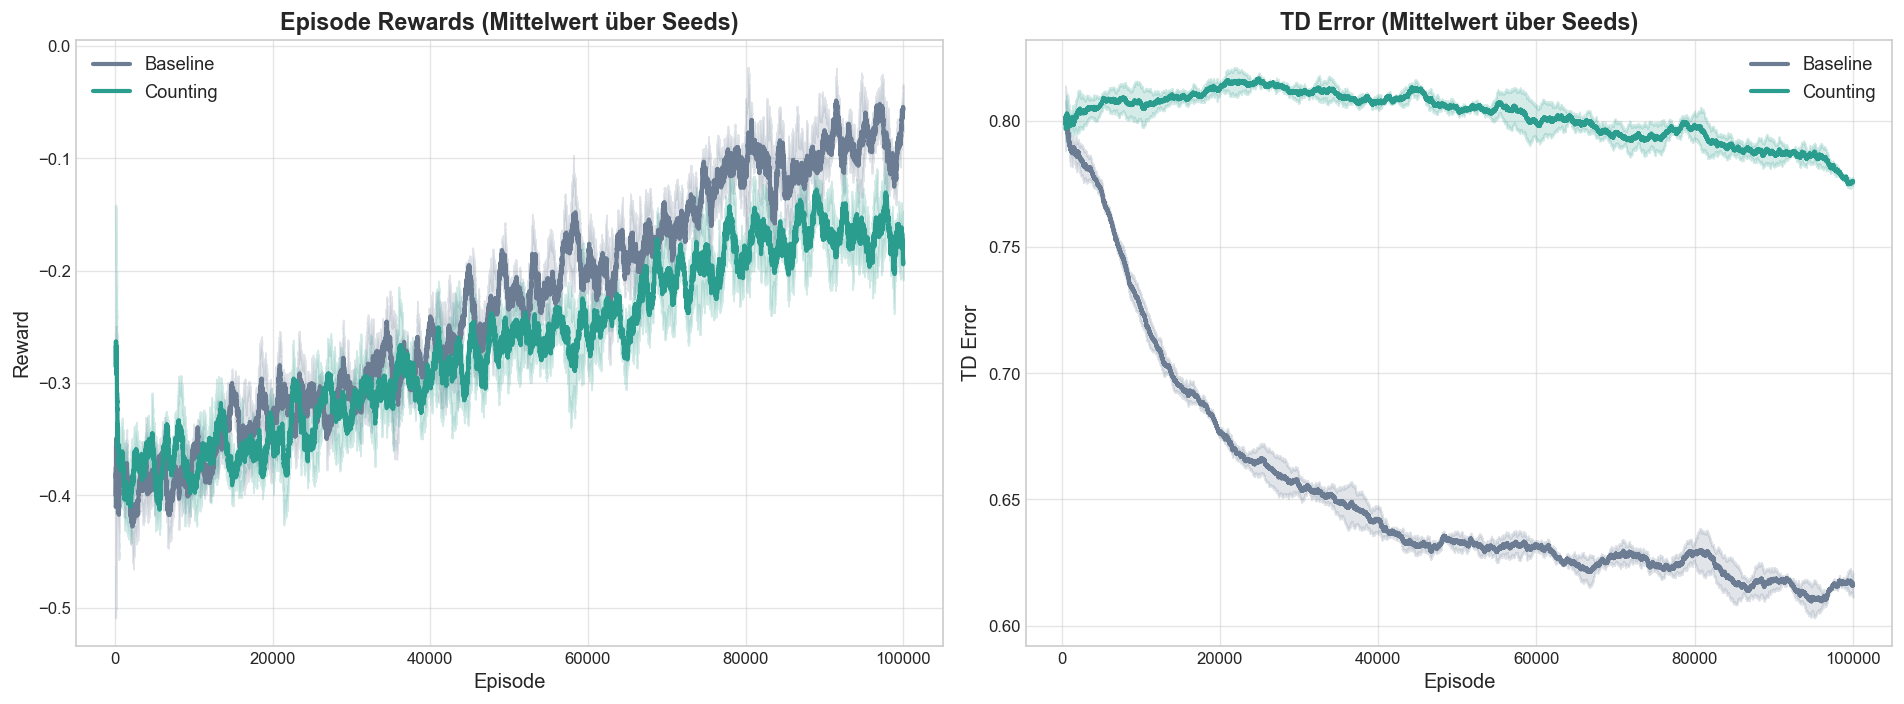

In [12]:
plot_all(agents, reward_window=1000, td_window=5000)

## Performance Comparison

In [13]:
print("Starte Trainings-Auswertung der Agenten...\n")

def get_reward_matrix(agent_list):
    return np.vstack([
        np.asarray(agent.episode_rewards)
        for seed, agent in agent_list
    ])


def flatten_rewards(agent_list):
    return get_reward_matrix(agent_list).ravel()


def calculate_metrics(rewards: np.ndarray) -> dict:
    rewards = np.asarray(rewards)

    wins = np.sum(rewards == 1)
    losses = np.sum(rewards == -1)
    pushes = np.sum(rewards == 0)
    total = len(rewards)

    return {
        "win_rate": wins / total if total > 0 else 0.0,
        "loss_rate": losses / total if total > 0 else 0.0,
        "push_rate": pushes / total if total > 0 else 0.0,
        "average_reward": np.mean(rewards) if total > 0 else 0.0,
        "std_reward": np.std(rewards) if total > 0 else 0.0,
    }


grouped = group_agents_by_type(agents)

per_seed_rows = []
for agent_type, agent_list in grouped.items():
    for seed, agent in agent_list:
        row = calculate_metrics(np.asarray(agent.episode_rewards))
        row.update({"agent_type": agent_type, "seed": seed})
        per_seed_rows.append(row)

per_seed_metrics_df = pd.DataFrame(per_seed_rows).sort_values(["agent_type", "seed"])
display(per_seed_metrics_df)

baseline_rewards = flatten_rewards(grouped["baseline"])
counting_rewards = flatten_rewards(grouped["counting"])

baseline_metrics = calculate_metrics(baseline_rewards)
counting_metrics = calculate_metrics(counting_rewards)

summary_metrics_df = pd.DataFrame({
    "baseline": baseline_metrics,
    "counting": counting_metrics,
}).T
display(summary_metrics_df)

for name, metrics in [("Baseline", baseline_metrics), ("Counting", counting_metrics)]:
    print(f"{name} metrics:")
    print(f"  Win Rate:       {metrics['win_rate']:.1%}")
    print(f"  Loss Rate:      {metrics['loss_rate']:.1%}")
    print(f"  Push Rate:      {metrics['push_rate']:.1%}")
    print(f"  Avg Reward:     {metrics['average_reward']:.3f}")
    print(f"  Std Reward:     {metrics['std_reward']:.3f}")
    print()


Starte Trainings-Auswertung der Agenten...



,win_rate,loss_rate,push_rate,average_reward,std_reward,agent_type,seed
0,0.35255,0.58179,0.06566,-0.22924,0.939036,baseline,1
1,0.35423,0.58156,0.06421,-0.22733,0.940272,baseline,42
2,0.35167,0.58101,0.06732,-0.22934,0.938127,baseline,123
3,0.33740,0.60492,0.05768,-0.26752,0.933141,counting,1
4,0.33991,0.60374,0.05635,-0.26383,0.934903,counting,42
5,0.33892,0.60492,0.05616,-0.26600,0.934390,counting,123


,win_rate,loss_rate,push_rate,average_reward,std_reward
baseline,0.352817,0.581453,0.06573,-0.228637,0.939146
counting,0.338743,0.604527,0.05673,-0.265783,0.934146


Baseline metrics:
  Win Rate:       35.3%
  Loss Rate:      58.1%
  Push Rate:      6.6%
  Avg Reward:     -0.229
  Std Reward:     0.939

Counting metrics:
  Win Rate:       33.9%
  Loss Rate:      60.5%
  Push Rate:      5.7%
  Avg Reward:     -0.266
  Std Reward:     0.934



Zusammenfassung pro Seed:


,agent_name,train_seed,eval_seed,source,episodes,win_rate,loss_rate,push_rate,average_reward
baseline-1__eval_seed_1234,baseline-1,1,1234,in_memory,10000,0.429,0.4736,0.0974,-0.0446
baseline-1__eval_seed_4321,baseline-1,1,4321,in_memory,10000,0.4327,0.4727,0.0946,-0.04
baseline-1__eval_seed_9876,baseline-1,1,9876,in_memory,10000,0.4283,0.4795,0.0922,-0.0512
counting-1__eval_seed_1234,counting-1,1,1234,in_memory,10000,0.3886,0.5364,0.075,-0.1478
counting-1__eval_seed_4321,counting-1,1,4321,in_memory,10000,0.3869,0.5397,0.0734,-0.1528
counting-1__eval_seed_9876,counting-1,1,9876,in_memory,10000,0.3929,0.5331,0.074,-0.1402
baseline-42__eval_seed_1234,baseline-42,42,1234,in_memory,10000,0.4255,0.4807,0.0938,-0.0552
baseline-42__eval_seed_4321,baseline-42,42,4321,in_memory,10000,0.424,0.4804,0.0956,-0.0564
baseline-42__eval_seed_9876,baseline-42,42,9876,in_memory,10000,0.433,0.4694,0.0976,-0.0364
counting-42__eval_seed_1234,counting-42,42,1234,in_memory,10000,0.3872,0.5342,0.0786,-0.147



Berechne mathematische 95% Konfidenzintervalle:


,win_rate,Win Rate 95% CI,loss_rate,Loss Rate 95% CI,push_rate,Push Rate 95% CI,average_reward,Avg Reward 95% CI
baseline-1__eval_seed_1234,0.4290,"[0.4193, 0.4387]",0.4736,"[0.4638, 0.4834]",0.0974,"[0.0916, 0.1032]",-0.0446,"[-0.0632, -0.0260]"
baseline-1__eval_seed_4321,0.4327,"[0.4230, 0.4424]",0.4727,"[0.4629, 0.4825]",0.0946,"[0.0889, 0.1003]",-0.0400,"[-0.0586, -0.0214]"
baseline-1__eval_seed_9876,0.4283,"[0.4186, 0.4380]",0.4795,"[0.4697, 0.4893]",0.0922,"[0.0865, 0.0979]",-0.0512,"[-0.0698, -0.0326]"
counting-1__eval_seed_1234,0.3886,"[0.3790, 0.3982]",0.5364,"[0.5266, 0.5462]",0.0750,"[0.0698, 0.0802]",-0.1478,"[-0.1664, -0.1292]"
counting-1__eval_seed_4321,0.3869,"[0.3774, 0.3964]",0.5397,"[0.5299, 0.5495]",0.0734,"[0.0683, 0.0785]",-0.1528,"[-0.1714, -0.1342]"
counting-1__eval_seed_9876,0.3929,"[0.3833, 0.4025]",0.5331,"[0.5233, 0.5429]",0.0740,"[0.0689, 0.0791]",-0.1402,"[-0.1589, -0.1215]"
baseline-42__eval_seed_1234,0.4255,"[0.4158, 0.4352]",0.4807,"[0.4709, 0.4905]",0.0938,"[0.0881, 0.0995]",-0.0552,"[-0.0738, -0.0366]"
baseline-42__eval_seed_4321,0.4240,"[0.4143, 0.4337]",0.4804,"[0.4706, 0.4902]",0.0956,"[0.0898, 0.1014]",-0.0564,"[-0.0750, -0.0378]"
baseline-42__eval_seed_9876,0.4330,"[0.4233, 0.4427]",0.4694,"[0.4596, 0.4792]",0.0976,"[0.0918, 0.1034]",-0.0364,"[-0.0550, -0.0178]"
counting-42__eval_seed_1234,0.3872,"[0.3777, 0.3967]",0.5342,"[0.5244, 0.5440]",0.0786,"[0.0733, 0.0839]",-0.1470,"[-0.1656, -0.1284]"



Generiere 2x2 Signifikanz-Plots...
Figure saved: C:\Users\lipal\IdeaProjects\ml-blackjack\images\final_evaluation_metrics_with_cis.png


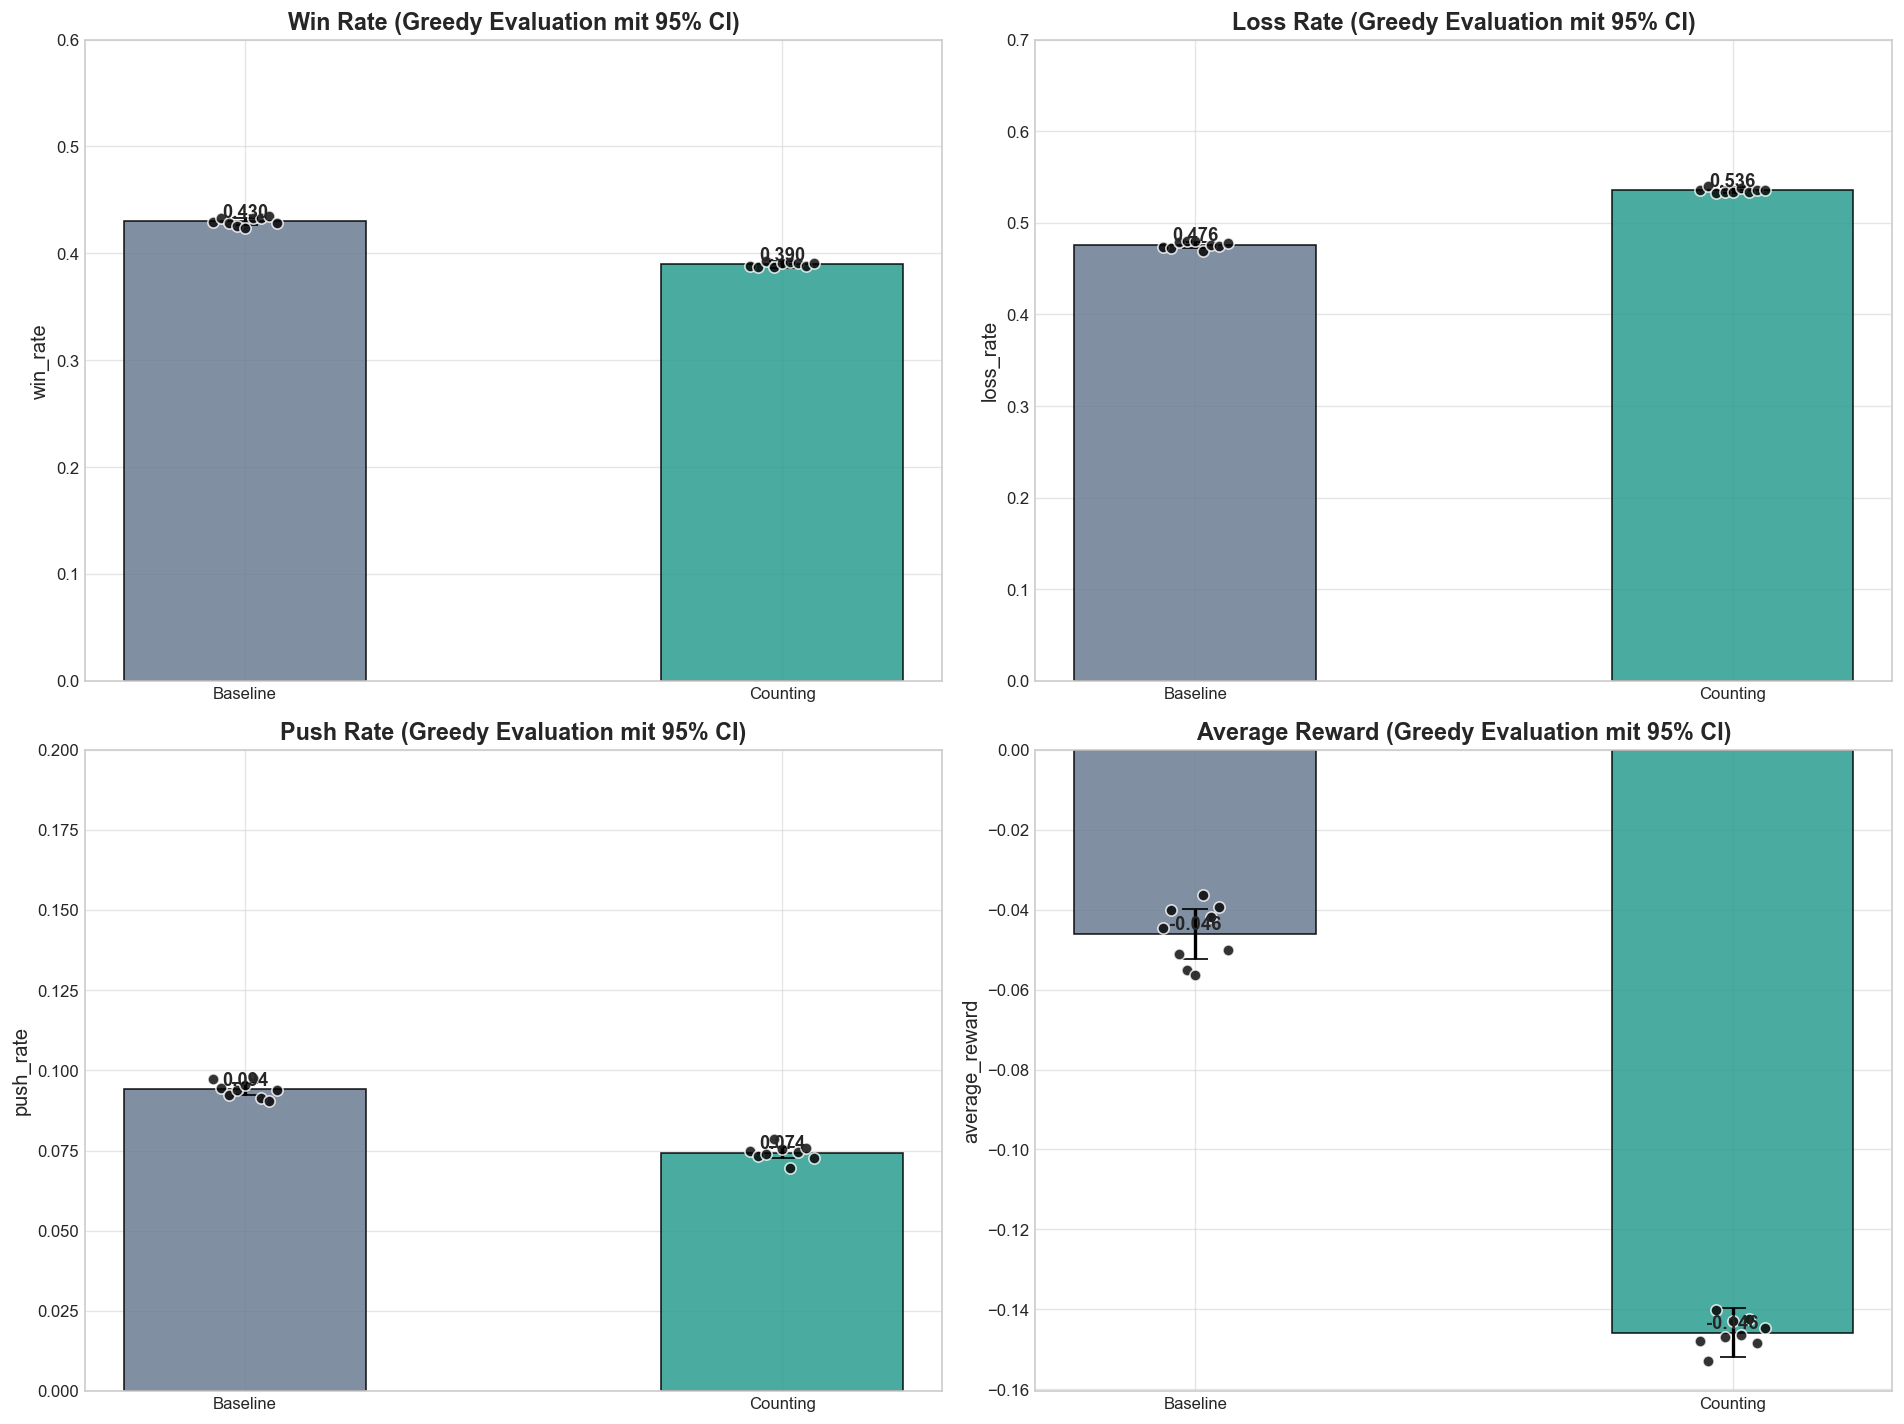

In [14]:
greedy_eval_data = globals().get("greedy_eval_df")
if greedy_eval_data is None:
    raise RuntimeError("Bitte zuerst die Greedy-Evaluation ausführen.")

evaluation_dir = globals().get("EVALUATION_DIR")

from utils.evaluation import calculate_evaluation_cis, plot_evaluation_metrics_with_cis

print("Zusammenfassung pro Seed:")
display(greedy_eval_data[["agent_name", "train_seed", "eval_seed", "source", "episodes", "win_rate", "loss_rate", "push_rate", "average_reward"]])

print("\nBerechne mathematische 95% Konfidenzintervalle:")
greedy_eval_ci_df = calculate_evaluation_cis(greedy_eval_data)
display(greedy_eval_ci_df)
if evaluation_dir is not None:
    greedy_eval_ci_df.to_csv(evaluation_dir / "greedy_metrics_ci.csv", index_label="eval_run")

print("\nGeneriere 2x2 Signifikanz-Plots...")
greedy_eval_plot_df = greedy_eval_data.drop(
    columns=["agent_name", "agent_type", "train_seed", "eval_seed"],
    errors="ignore",
)

plot_evaluation_metrics_with_cis(
    greedy_eval_df=greedy_eval_plot_df,
    agent_styles=AGENT_STYLES,
    split_agent_name_func=lambda task_name: split_agent_name(split_eval_task_name(task_name)[0]),
    save_fig_func=save_fig
)


In [15]:
from utils.evaluation import (
    TRUE_COUNT_BUCKET_SUMMARY_COLUMNS,
    build_true_count_bucket_tasks,
    create_true_count_bucket_widget,
    evaluate_true_count_buckets_parallel,
    prepare_true_count_bucket_reports,
)

TRUE_COUNT_BUCKETS = [
    ("<= -3", None, -3),
    ("-2 to 0", -2, 0),
    ("1 to 2", 1, 2),
    (">= 3", 3, None),
]

if "EVAL_ARTIFACT_SELECTORS" not in globals():
    raise RuntimeError("Bitte zuerst die Evaluation-Artefakte auswählen.")

bucket_tasks, bucket_agent_names = build_true_count_bucket_tasks(
    agents=agents,
    selected_eval_agent_func=selected_eval_agent,
    split_agent_name_func=split_agent_name,
    eval_task_name_func=eval_task_name,
    baseline_state_key_func=baseline_state_key,
    counting_state_key_func=counting_state_key,
    eval_seeds=EVAL_SEEDS,
    eval_episodes=EVAL_EPISODES,
    buckets=TRUE_COUNT_BUCKETS,
)

bucket_results = run_parallel_with_dashboard(
    worker_func=evaluate_true_count_buckets_parallel,
    base_tasks=bucket_tasks,
    agent_names=bucket_agent_names,
    max_value_per_agent=EVAL_EPISODES,
    title="True-Count-Bucket-Evaluation",
)

evaluation_dir = globals().get("EVALUATION_DIR")
if evaluation_dir is None:
    evaluation_dir = MODEL_DIR / "evaluations" / RUN_ID
    evaluation_dir.mkdir(parents=True, exist_ok=True)
    EVALUATION_DIR = evaluation_dir

true_count_bucket_raw_df, true_count_bucket_summary_df, true_count_bucket_seed_df = prepare_true_count_bucket_reports(
    bucket_results=bucket_results,
    split_eval_task_name_func=split_eval_task_name,
    split_agent_name_func=split_agent_name,
    evaluation_dir=evaluation_dir,
)

print(f"True-Count-Bucket-Auswertung gespeichert unter: {evaluation_dir}")
display(true_count_bucket_summary_df[TRUE_COUNT_BUCKET_SUMMARY_COLUMNS])
display(create_true_count_bucket_widget(
    summary_df=true_count_bucket_summary_df,
    seed_df=true_count_bucket_seed_df,
    buckets=TRUE_COUNT_BUCKETS,
))


Initialisiere paralleles True-Count-Bucket-Evaluation-Dashboard...



Prozess erfolgreich beendet! Gesamtdauer: 0:00:40
True-Count-Bucket-Auswertung gespeichert unter: C:\Users\lipal\IdeaProjects\ml-blackjack\models\evaluations\20260605_191814


,aggregation,comparison_id,bucket,episodes,average_reward,win_rate,loss_rate,push_rate,hit_rate,stand_rate
0,mean,baseline (all seeds),<= -3,7855,-0.044552,0.425996,0.470548,0.103456,0.467879,0.532121
1,mean,baseline (all seeds),-2 to 0,57076,-0.036860,0.433336,0.470196,0.096469,0.472591,0.527409
2,mean,baseline (all seeds),1 to 2,17061,-0.075373,0.419153,0.494526,0.086321,0.489898,0.510102
3,mean,baseline (all seeds),>= 3,8008,-0.053379,0.429958,0.483337,0.086705,0.489503,0.510497
4,mean,counting (all seeds),<= -3,8420,-0.162442,0.382772,0.545213,0.072015,0.262869,0.737131
5,mean,counting (all seeds),-2 to 0,56725,-0.129904,0.395729,0.525634,0.078637,0.402042,0.597958
6,mean,counting (all seeds),1 to 2,16931,-0.161782,0.384096,0.545878,0.070026,0.400851,0.599149
7,mean,counting (all seeds),>= 3,7924,-0.188109,0.379824,0.567934,0.052242,0.267593,0.732407
8,median,baseline (all seeds),<= -3,7855,-0.043320,0.428745,0.472065,0.103460,0.470908,0.529092
9,median,baseline (all seeds),-2 to 0,57076,-0.041505,0.431077,0.472581,0.096408,0.474959,0.525041


interactive(children=(Dropdown(description='Metrik:', options=('average_reward', 'win_rate', 'loss_rate', 'pus…

# Policy & Q-Value Visualization
Hier analysieren wir interaktiv die gelernten Strategien der Agenten und vergleichen sie mit der Basic Strategy.

In [16]:
import ipywidgets as widgets
from utils.visualizations import plot_policy_and_q_values

def interactive_plot_wrapper(agent_name, true_count):
    if agent_name in agents:
        plot_policy_and_q_values(
            agent=agents[agent_name], 
            agent_name=agent_name, 
            split_agent_name_func=split_agent_name, 
            save_fig_func=save_fig, 
            true_count=true_count
        )

# --- STEUERUNG FÜR AGENT A (LINKS) ---
agent_selector_a = widgets.Dropdown(options=list(agents.keys()), value=list(agents.keys())[0], description='Agent A:')
true_count_slider_a = widgets.IntSlider(value=0, min=-10, max=10, step=1, description='True Count A:', disabled=True)

def update_slider_visibility_a(*args):
    agent_type, _ = split_agent_name(agent_selector_a.value)
    true_count_slider_a.disabled = (agent_type == "baseline")

agent_selector_a.observe(update_slider_visibility_a, 'value')
plot_a = widgets.interactive(interactive_plot_wrapper, agent_name=agent_selector_a, true_count=true_count_slider_a)


# --- STEUERUNG FÜR AGENT B (RECHTS) ---
# Startwert auf den letzten Eintrag gesetzt, damit direkt zwei unterschiedliche Agenten laden
agent_selector_b = widgets.Dropdown(options=list(agents.keys()), value=list(agents.keys())[-1], description='Agent B:')
true_count_slider_b = widgets.IntSlider(value=0, min=-10, max=10, step=1, description='True Count B:', disabled=True)

def update_slider_visibility_b(*args):
    agent_type, _ = split_agent_name(agent_selector_b.value)
    true_count_slider_b.disabled = (agent_type == "baseline")

agent_selector_b.observe(update_slider_visibility_b, 'value')
plot_b = widgets.interactive(interactive_plot_wrapper, agent_name=agent_selector_b, true_count=true_count_slider_b)

update_slider_visibility_a()
update_slider_visibility_b()

widgets.HBox([plot_a, plot_b])